# Name: Gaurav Sahoo & Neha Garg
# Assignment: Stock Price Prediction Using RNNs

## Objective
The objective of this assignment is to try and predict the stock prices using historical data from four companies IBM (IBM), Google (GOOGL), Amazon (AMZN), and Microsoft (MSFT).

We use four different companies because they belong to the same sector: Technology. Using data from all four companies may improve the performance of the model. This way, we can capture the broader market sentiment.

The problem statement for this assignment can be summarised as follows:

> Given the stock prices of Amazon, Google, IBM, and Microsoft for a set number of days, predict the stock price of these companies after that window.

## Business Value

Data related to stock markets lends itself well to modeling using RNNs due to its sequential nature. We can keep track of opening prices, closing prices, highest prices, and so on for a long period of time as these values are generated every working day. The patterns observed in this data can then be used to predict the future direction in which stock prices are expected to move. Analyzing this data can be interesting in itself, but it also has a financial incentive as accurate predictions can lead to massive profits.

### **Data Description**

You have been provided with four CSV files corresponding to four stocks: AMZN, GOOGL, IBM, and MSFT. The files contain historical data that were gathered from the websites of the stock markets where these companies are listed: NYSE and NASDAQ. The columns in all four files are identical. Let's take a look at them:

- `Date`: The values in this column specify the date on which the values were recorded. In all four files, the dates range from Jaunary 1, 2006 to January 1, 2018.

- `Open`: The values in this column specify the stock price on a given date when the stock market opens.

- `High`: The values in this column specify the highest stock price achieved by a stock on a given date.

- `Low`: The values in this column specify the lowest stock price achieved by a stock on a given date.

- `Close`: The values in this column specify the stock price on a given date when the stock market closes.

- `Volume`: The values in this column specify the total number of shares traded on a given date.

- `Name`: This column gives the official name of the stock as used in the stock market.

There are 3019 records in each data set. The file names are of the format `\<company_name>_stock_data.csv`.

## **1 Data Loading and Preparation** <font color =red> [25 marks] </font>

#### **Import Necessary Libraries**

In [1]:
# Import libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_absolute_error

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Input, Dense

/Users/gauravsahoo/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### **1.1 Data Aggregation** <font color =red> [7 marks] </font>

As we are using the stock data for four different companies, we need to create a new DataFrame that contains the combined data from all four data frames. We will create a function that takes in a list of the file names for the four CSV files, and returns a single data frame. This function performs the following tasks:
- Extract stock names from file names
- Read the CSV files as data frames
- Append the stock names into the columns of their respective data frames
- Drop unnecessary columns
- Join the data frames into one.

#### **1.1.1** <font color =red> [5 marks] </font>
Create the function to join DataFrames and use it to combine the four datasets.

In [2]:
# Define a function to load data and aggregate them
def aggregate_data(csvFiles):
    master_df = pd.DataFrame()
    for csvFile in csvFiles:
        df = pd.read_csv(csvFile)
        stockName = df['Name'].unique()[0]
        print(f'Stock {stockName} : Shape {df.shape}')
        df['Date'] = pd.to_datetime(df['Date'])

        rename_columns = {
            'Open': f'Open{stockName}',
            'High': f'High{stockName}',
            'Low': f'Low{stockName}',
            'Close': f'Close{stockName}',
            'Volume': f'Volume{stockName}',
        }

        df.rename(columns=rename_columns, inplace=True)
        df.drop(columns=['Name'], inplace=True)

        if master_df.empty:
            master_df = df
        else:
            master_df = pd.merge(master_df, df, on='Date', how='outer')
    
    return master_df

In [3]:
# Specify the names of the raw data files to be read and use the aggregation function to read the files
csv_files = [
    'RNN_Stocks_Data/AMZN_stocks_data.csv',
    'RNN_Stocks_Data/GOOGL_stocks_data.csv',
    'RNN_Stocks_Data/IBM_stocks_data.csv',
    'RNN_Stocks_Data/MSFT_stocks_data.csv'
]

master_df = aggregate_data(csv_files)

master_df.set_index('Date', inplace=True)
master_df.head()

Stock AMZN : Shape (3019, 7)
Stock GOOGL : Shape (3019, 7)
Stock IBM : Shape (3020, 7)
Stock MSFT : Shape (3019, 7)


,OpenAMZN,HighAMZN,LowAMZN,CloseAMZN,VolumeAMZN,OpenGOOGL,HighGOOGL,LowGOOGL,CloseGOOGL,VolumeGOOGL,OpenIBM,HighIBM,LowIBM,CloseIBM,VolumeIBM,OpenMSFT,HighMSFT,LowMSFT,CloseMSFT,VolumeMSFT
Date,,,,,,,,,,,,,,,,,,,,
2006-01-03,47.47,47.85,46.25,47.58,7582127.0,211.47,218.05,209.32,217.83,13137450.0,82.45,82.55,80.81,82.06,11715200,26.25,27.00,26.10,26.84,79974418.0
2006-01-04,47.48,47.73,46.69,47.25,7440914.0,222.17,224.70,220.09,222.84,15292353.0,82.20,82.50,81.33,81.95,9840600,26.77,27.08,26.77,26.97,57975661.0
2006-01-05,47.16,48.20,47.11,47.65,5417258.0,223.22,226.00,220.97,225.85,10815661.0,81.40,82.90,81.00,82.50,7213500,26.96,27.13,26.91,26.99,48247610.0
2006-01-06,47.97,48.58,47.32,47.87,6154285.0,228.66,235.49,226.85,233.06,17759521.0,83.95,85.03,83.41,84.95,8197400,26.89,27.00,26.49,26.91,100969092.0
2006-01-09,46.55,47.10,46.40,47.08,8945056.0,233.44,236.94,230.70,233.68,12795837.0,84.10,84.25,83.38,83.73,6858200,26.93,27.07,26.76,26.86,55627836.0


* All the stock datasets contain seven columns, as mentioned in the data description.

* AMZN, GOOGL, and MSFT each have 3019 rows, while IBM has 3020 rows.

In [4]:
# View specifics of the data
pd.options.display.float_format = '{:.2f}'.format
pd.set_option('display.max_columns', None)

print(master_df.info())
print(master_df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3020 entries, 2006-01-03 to 2017-12-29
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   OpenAMZN     3019 non-null   float64
 1   HighAMZN     3019 non-null   float64
 2   LowAMZN      3019 non-null   float64
 3   CloseAMZN    3019 non-null   float64
 4   VolumeAMZN   3019 non-null   float64
 5   OpenGOOGL    3019 non-null   float64
 6   HighGOOGL    3019 non-null   float64
 7   LowGOOGL     3019 non-null   float64
 8   CloseGOOGL   3019 non-null   float64
 9   VolumeGOOGL  3019 non-null   float64
 10  OpenIBM      3019 non-null   float64
 11  HighIBM      3020 non-null   float64
 12  LowIBM       3019 non-null   float64
 13  CloseIBM     3020 non-null   float64
 14  VolumeIBM    3020 non-null   int64  
 15  OpenMSFT     3019 non-null   float64
 16  HighMSFT     3019 non-null   float64
 17  LowMSFT      3019 non-null   float64
 18  CloseMSFT    3019 non-null   f

* After merging all the stock datasets on the Date column and setting it as index, the resulting DataFrame contains 3020 rows and 20 columns.

#### **1.1.2** <font color =red> [2 marks] </font>
Identify and handle any missing values.

In [5]:
# Handle Missing Values
print(master_df.isnull().sum())

master_df.dropna(inplace=True)

print(f'The final shape of dataframe after dropping the missing values : {master_df.shape}')

OpenAMZN       1
HighAMZN       1
LowAMZN        1
CloseAMZN      1
VolumeAMZN     1
OpenGOOGL      1
HighGOOGL      1
LowGOOGL       1
CloseGOOGL     1
VolumeGOOGL    1
OpenIBM        1
HighIBM        0
LowIBM         1
CloseIBM       0
VolumeIBM      0
OpenMSFT       1
HighMSFT       1
LowMSFT        1
CloseMSFT      1
VolumeMSFT     1
dtype: int64
The final shape of dataframe after dropping the missing values : (3018, 20)


* After dropping two rows (~0.07% of total rows), the resulting DataFrame contains 3018 rows and 21 columns.

### **1.2 Analysis and Visualisation** <font color =red> [5 marks] </font>

#### **1.2.1** <font color =red> [2 marks] </font>
Analyse the frequency distribution of stock volumes of the companies and also see how the volumes vary over time.

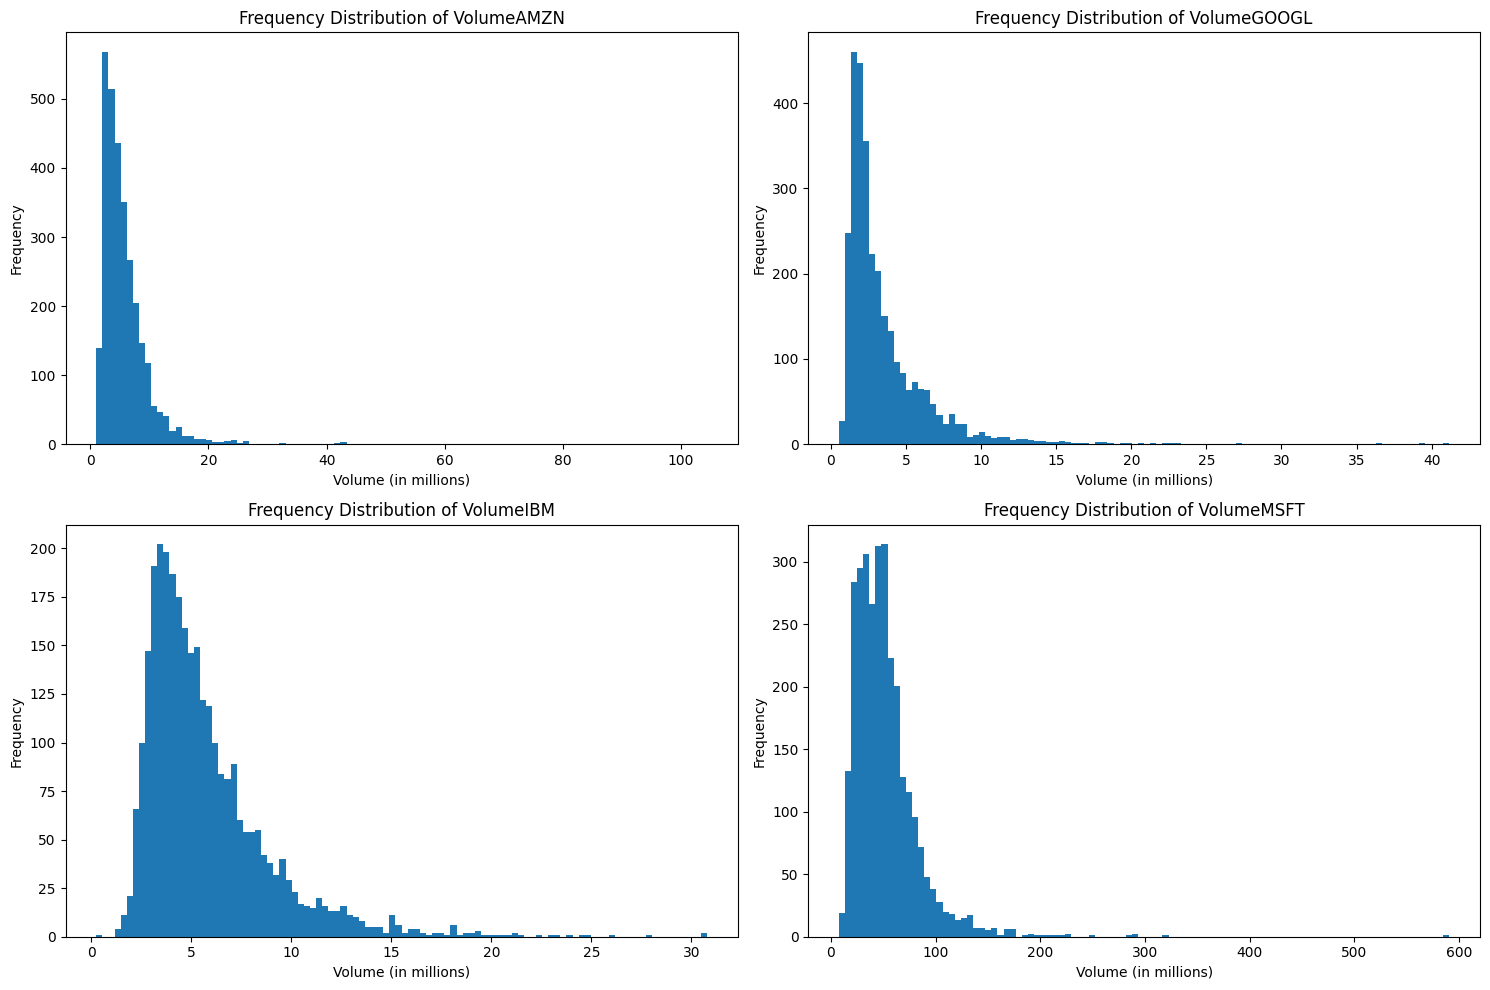

In [6]:
# Frequency distribution of volumes
volume_columns = [stock_volume for stock_volume in master_df.columns if 'Volume' in stock_volume]

plt.figure(figsize=(15, 10))
for pos, stock_volume in enumerate(volume_columns):
    plt.subplot(2, 2, pos + 1)
    plt.hist(master_df[stock_volume]/1000000, bins=100)
    plt.title(f'Frequency Distribution of {stock_volume}')
    plt.xlabel('Volume (in millions)')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

* All the frequency plots show that the data is right-skewed, which shows that most trading occurs at lower volumes.

* The trading frequency for AMZN stock is high at lower volume levels, compared to other stocks.

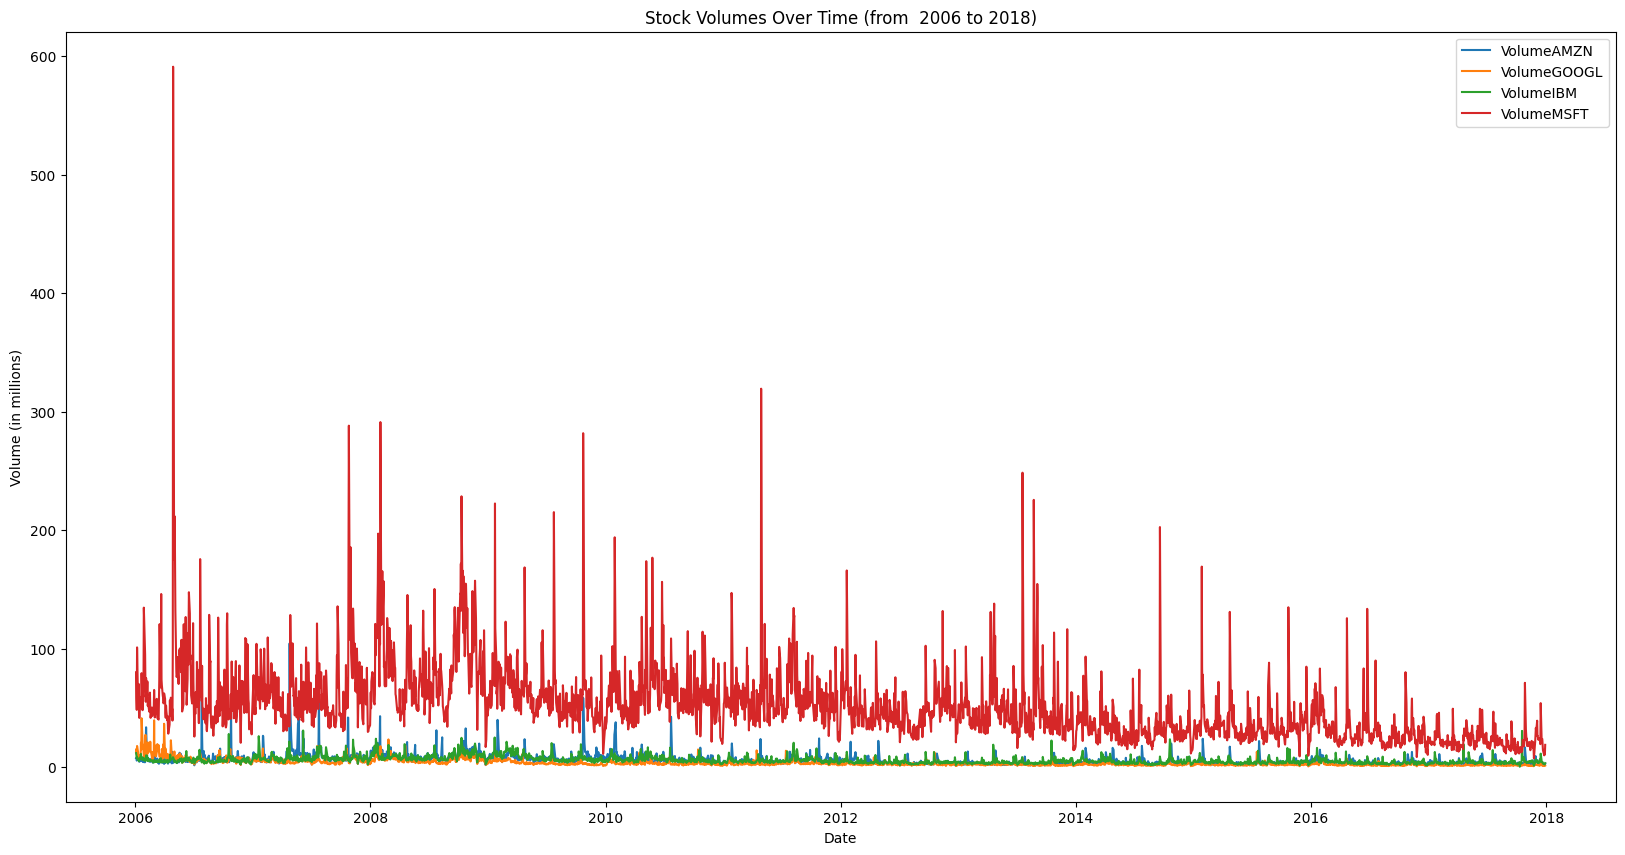

In [7]:
# Stock volume variation over time
plt.figure(figsize=(20, 10))
for stock_volume in volume_columns:
    plt.plot(master_df.index, master_df[stock_volume]/1000000, label=stock_volume)
plt.title('Stock Volumes Over Time (from  2006 to 2018)')
plt.xlabel('Date')
plt.ylabel('Volume (in millions)')
plt.legend()
plt.show()

* The trading volume of MSFT is significantly higher compared to other stocks but has decreased over time.

* The trading volumes of other stocks (AMZN, GOOGL, IBM) are relatively similar, although on some days, AMZN had a higher trading volume.

#### **1.2.2** <font color =red> [3 marks] </font>
Analyse correlations between features.

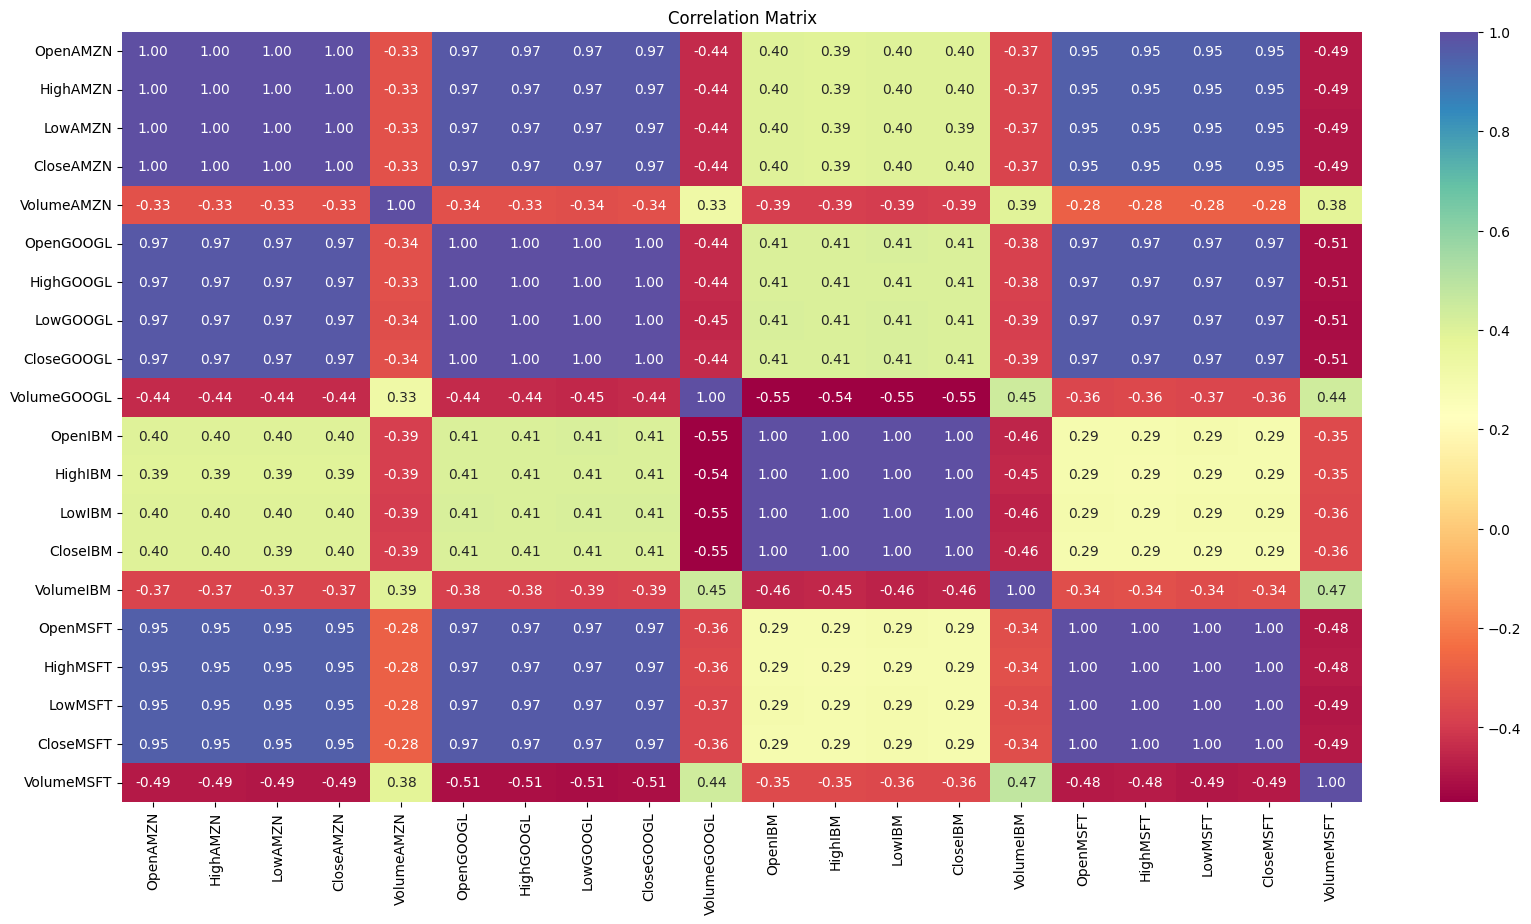

In [8]:
# Analyse correlations
plt.figure(figsize=(20, 10))
sns.heatmap(master_df.corr(), annot=True, fmt='.2f', cmap='Spectral')
plt.title('Correlation Matrix')
plt.show()

* The stock prices of AMZN, GOOGL, and MSFT show a strong correlation with each other, while they show a weaker correlation with IBM.

### **1.3 Data Processing** <font color =red> [13 marks] </font>

Next, we need to process the data so that it is ready to be used in recurrent neural networks. You know RNNs are suitable to work with sequential data where patterns repeat at regular intervals.

For this, we need to execute the following steps:
1. Create windows from the master data frame and obtain windowed `X` and corresponding windowed `y` values
2. Perform train-test split on the windowed data
3. Scale the data sets in an appropriate manner

We will define functions for the above steps that finally return training and testing data sets that are ready to be used in recurrent neural networks.

**Hint:** If we use a window of size 3, in the first window, the rows `[0, 1, 2]` will be present and will be used to predict the value of `CloseAMZN` in row `3`. In the second window, rows `[1, 2, 3]` will be used to predict `CloseAMZN` in row `4`.

#### **1.3.1** <font color =red> [3 marks] </font>
Create a function that returns the windowed `X` and `y` data.

From the main DataFrame, this function will create windowed DataFrames, and store those as a list of DataFrames.

Controllable parameters will be window size, step size (window stride length) and target names as a list of the names of stocks whose closing values we wish to predict.

In [9]:
# Define a function that divides the data into windows and generates target variable values for each window
def create_windows(data, window_size, window_stride, target_names):
    windows = []
    targets = []

    for i in range(0, len(data) - window_size, window_stride):
        window = data.iloc[i:i + window_size]
        target = data[target_names].iloc[i + window_size]
        windows.append(window)
        targets.append(target)
    
    return np.array(windows), np.array(targets)

#### **1.3.2** <font color =red> [3 marks] </font>
Create a function to scale the data.

Define a function that will scale the data.

For scaling, we have to look at the whole length of data to find max/min values or standard deviations and means. If we scale the whole data at once, this will lead to data leakage in the windows. This is not necessarily a problem if the model is trained on the complete data with cross-validation.

One way to scale when dealing with windowed data is to use the `partial_fit()` method.
```
scaler.partial_fit(window)
scaler.transform(window)
```
You may use any other suitable way to scale the data properly. Arrive at a reasonable way to scale your data.

In [10]:
# Define a function that scales the windowed data
# The function takes in the windowed data sets and returns the scaled windows
def scale_windows(windows, scaler):
    scaled_windows = []

    for window in windows:
        scaler.partial_fit(window)
    
    for window in windows:
        scaled_window = scaler.transform(window)
        scaled_windows.append(scaled_window)

    return np.array(scaled_windows)

Next, define the main function that will call the windowing and scaling helper functions.

The input parameters for this function are:
- The joined master data set
- The names of the stocks that we wish to predict the *Close* prices for
- The window size
- The window stride
- The train-test split ratio

The outputs from this function are the scaled dataframes:
- *X_train*
- *y_train*
- *X_test*
- *y_test*

#### **1.3.3** <font color =red> [3 marks] </font>
Define a function to create windows of `window_size` and split the windowed data in to training and validation sets.

The function can take arguments such as list of target names, window size, window stride and split ratio. Use the windowing function here to make windows in the data and then perform scaling and train-test split.

In [11]:
# Define a function to create input and output data points from the master DataFrame
def create_data_points(master_df, target_names, window_size, window_stride, train_test_split_ratio):
    windows, targets = create_windows(master_df, window_size, window_stride, target_names)
    scaled_windows = scale_windows(windows, MinMaxScaler())
    
    split_index = int(len(scaled_windows) * (1 - train_test_split_ratio))

    X_train = scaled_windows[:split_index]
    y_train = targets[:split_index]
    X_test = scaled_windows[split_index:]
    y_test = targets[split_index:]
    
    return X_train, y_train, X_test, y_test

We can now use these helper functions to create our training and testing data sets. But first we need to decide on a length of windows. As we are doing time series prediction, we want to pick a sequence that shows some repetition of patterns.

For selecting a good sequence length, some business understanding will help us. In financial scenarios, we can either work with business days, weeks (which comprise of 5 working days), months, or quarters (comprising of 13 business weeks). Try looking for some patterns for these periods.

#### **1.3.4** <font color =red> [2 marks] </font>
Identify an appropriate window size.

For this, you can use plots to see how target variable is varying with time. Try dividing it into parts by weeks/months/quarters.

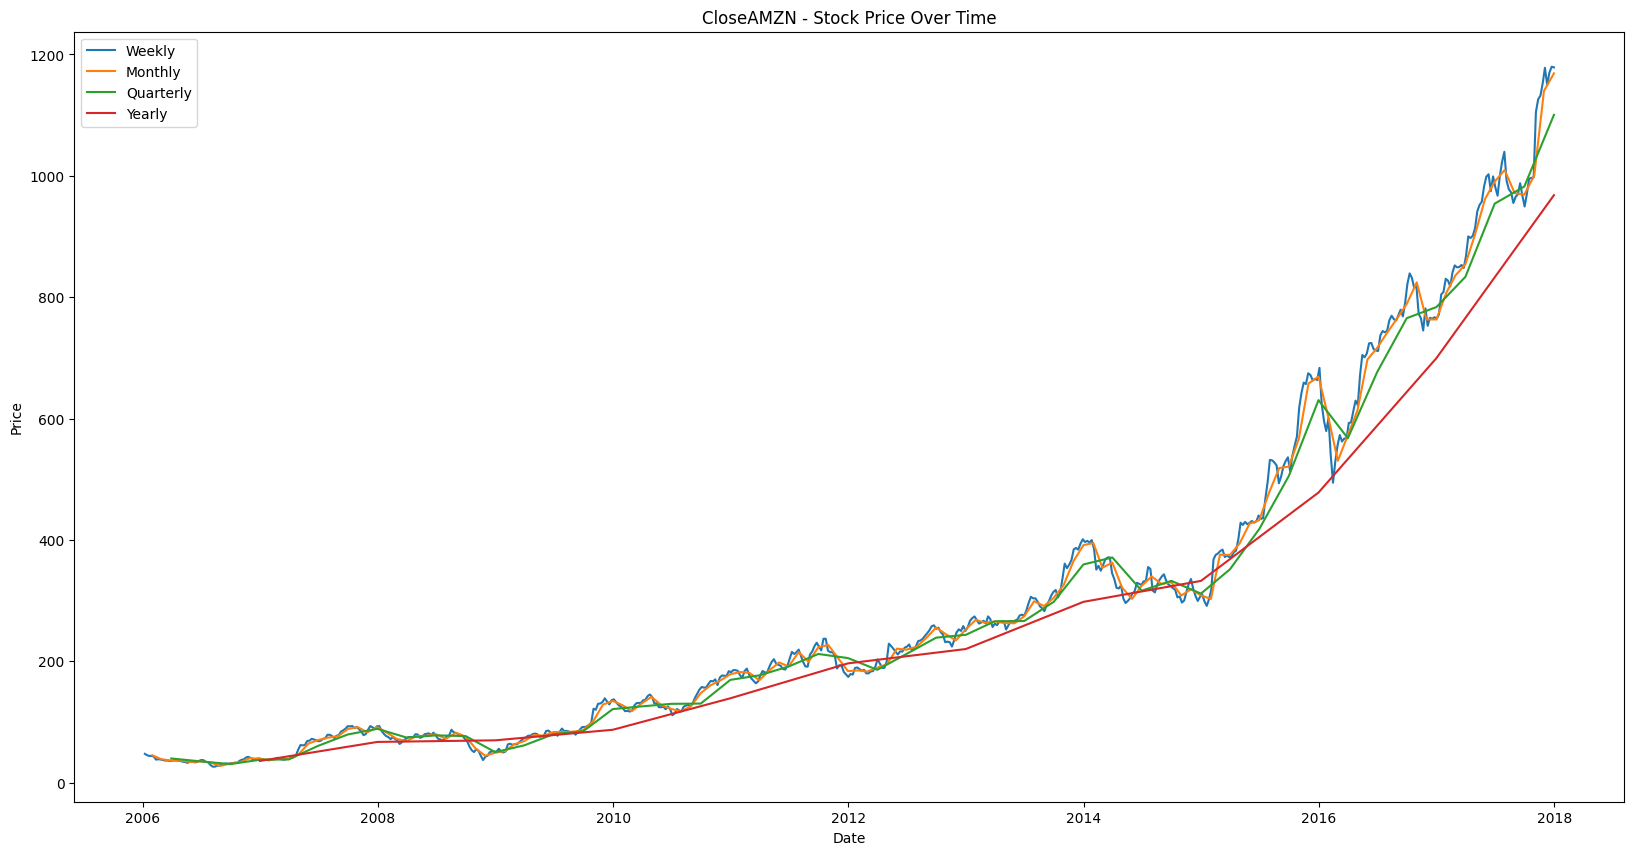

In [13]:
# Checking for patterns in different sequence lengths
target_names = ['CloseAMZN']

weekly_data = master_df.resample('W').mean()
monthly_data = master_df.resample('ME').mean()
quaterly_data = master_df.resample('QE').mean()
yearly_data = master_df.resample('YE').mean()


plt.figure(figsize=(20, 10))
plt.plot(weekly_data.index, weekly_data[target_names], label='Weekly')
plt.plot(monthly_data.index, monthly_data[target_names], label='Monthly')
plt.plot(quaterly_data.index, quaterly_data[target_names], label='Quarterly')
plt.plot(yearly_data.index, yearly_data[target_names], label='Yearly')
plt.title('CloseAMZN - Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

Using the Closing Price of AMZN for Analysis:

* Overall, the stock shows a upward trend over time.

* The weekly data captures more detailed price movements, making it suitable for predicting daily prices.

* The monthly data provides a balance between short-term fluctuations and long-term trends, offering a clearer view of medium-term price movements.

* The quaterly data has less noise but fails to capture short-term fluctuations, making it less effective for short-term predictions.

* The yearly trend also has lesser noise and fails to capture short-term fluctuations. Additionally, it shows a significant gap when compared to the daily data.

#### **1.3.5** <font color =red> [2 marks] </font>
Call the functions to create testing and training instances of predictor and target features.

* For Simple RNN, we will use daily data to train with a 5-days (1 week) window size.

* For Advanced RNN (LSTM), we will use weekly data to train with a 8-weeks (2 months) window size.

In [14]:
# Create data instances from the master data frame using decided window size and window stride
window_size = 5
window_stride = 1
train_test_split_ratio = 0.2
X_train, y_train, X_test, y_test = create_data_points(master_df, target_names, window_size, window_stride, train_test_split_ratio)

In [15]:
# Check the number of data points generated
print(f'Number of data points generated for training: {len(X_train)}')
print(f'Number of data points generated for testing: {len(X_test)}')

Number of data points generated for training: 2410
Number of data points generated for testing: 603


**Check if the training and testing datasets are in the proper format to feed into neural networks.**

In [16]:
# Check if the datasets are compatible inputs to neural networks
print("TRAINING DATA")
print(f'Shape of input sequences: {X_train.shape}')
print(f'Shape of output sequences: {y_train.shape}')
print("-"*50)
print("TESTING DATA")
print(f'Shape of input sequences: {X_test.shape}')
print(f'Shape of output sequences: {y_test.shape}')

TRAINING DATA
Shape of input sequences: (2410, 5, 20)
Shape of output sequences: (2410, 1)
--------------------------------------------------
TESTING DATA
Shape of input sequences: (603, 5, 20)
Shape of output sequences: (603, 1)


## **2 RNN Models** <font color =red> [20 marks] </font>

In this section, we will:
- Define a function that creates a simple RNN
- Tune the RNN for different hyperparameter values
- View the performance of the optimal model on the test data

### **2.1 Simple RNN Model** <font color =red> [10 marks] </font>

#### **2.1.1** <font color =red> [3 marks] </font>
Create a function that builds a simple RNN model based on the layer configuration provided.

* Using daily data to train a simple RNN model with a 5-days (1 week) window size.

In [17]:
# Create a function that creates a simple RNN model according to the model configuration arguments
def create_simple_rnn_model(input_shape, activation, loss, optimizer, rnn_units):
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(SimpleRNN(rnn_units, activation=activation))
    model.add(Dense(1))
    model.compile(loss=loss, optimizer=optimizer, metrics=['mean_absolute_error'])
    return model

#### **2.1.2** <font color =red> [4 marks] </font>
Perform hyperparameter tuning to find the optimal network configuration.

In [18]:
# Find an optimal configuration of simple RNN
network_configurations = {
    'activation': ['relu', 'tanh'],
    'loss': ['mse', 'mae'],
    'optimizer': ['adam', 'rmsprop', 'sgd'],
    'units': [32, 64, 128],
}

configurations_grid = ParameterGrid(network_configurations)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

simple_rnn_models = []
simple_rnn_configurations = []

for configuration in configurations_grid:
    print(f"\nTraining with config: {configuration}")
    model = create_simple_rnn_model(input_shape=(X_train.shape[1], X_train.shape[2]),
                                    activation=configuration['activation'],
                                    loss=configuration['loss'],
                                    optimizer=configuration['optimizer'],
                                    rnn_units=configuration['units'])
    history = model.fit(X_train, y_train, batch_size=32, epochs=20, validation_data=(X_test, y_test), callbacks=[early_stopping])
    simple_rnn_models.append(model)
    simple_rnn_configurations.append(configuration)


Training with config: {'activation': 'relu', 'loss': 'mse', 'optimizer': 'adam', 'units': 32}
Epoch 1/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 43043.1758 - mean_absolute_error: 171.9176 - val_loss: 545504.1250 - val_mean_absolute_error: 719.1225
Epoch 2/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step - loss: 14277.2402 - mean_absolute_error: 86.8941 - val_loss: 134569.1875 - val_mean_absolute_error: 349.6029
Epoch 3/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 795us/step - loss: 1929.6412 - mean_absolute_error: 34.2344 - val_loss: 100206.4844 - val_mean_absolute_error: 300.9225
Epoch 4/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step - loss: 977.7419 - mean_absolute_error: 23.1445 - val_loss: 61111.7344 - val_mean_absolute_error: 232.2490
Epoch 5/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 865us/step - loss: 633.0284 - mean_absolute_error: 19.4140 - val_loss: 49012.4336 - val_mean_absolute_error: 206.8481
Epoch 6/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 849us/step - loss: 500.6447 - mean_absolute_error: 17.0370 - v

In [19]:
# Find the best configuration based on evaluation metrics
best_model = None
best_config = None
best_test_loss = float('inf')

for i, model in enumerate(simple_rnn_models):
    test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
    print(f"Configuration {i + 1}: {simple_rnn_configurations[i]} - Test Loss: {test_loss}, Test MAE: {test_mae}")
    
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_model = model
        best_config = simple_rnn_configurations[i]

print(f"\nBest configuration: {best_config} with Test Loss: {best_test_loss}")

Configuration 1: {'activation': 'relu', 'loss': 'mse', 'optimizer': 'adam', 'units': 32} - Test Loss: 4481.40234375, Test MAE: 54.958839416503906
Configuration 2: {'activation': 'relu', 'loss': 'mse', 'optimizer': 'adam', 'units': 64} - Test Loss: 836.57958984375, Test MAE: 21.490013122558594
Configuration 3: {'activation': 'relu', 'loss': 'mse', 'optimizer': 'adam', 'units': 128} - Test Loss: 786.0247802734375, Test MAE: 20.63129234313965
Configuration 4: {'activation': 'relu', 'loss': 'mse', 'optimizer': 'rmsprop', 'units': 32} - Test Loss: 775.6234741210938, Test MAE: 21.163272857666016
Configuration 5: {'activation': 'relu', 'loss': 'mse', 'optimizer': 'rmsprop', 'units': 64} - Test Loss: 741.2828979492188, Test MAE: 19.660503387451172
Configuration 6: {'activation': 'relu', 'loss': 'mse', 'optimizer': 'rmsprop', 'units': 128} - Test Loss: 777.369140625, Test MAE: 20.533329010009766
Configuration 7: {'activation': 'relu', 'loss': 'mse', 'optimizer': 'sgd', 'units': 32} - Test Loss:

#### **2.1.3** <font color =red> [3 marks] </font>
Run for optimal Simple RNN Model and show final results.

In [20]:
# Create an RNN model with a combination of potentially optimal hyperparameter values and retrain the model
final_simple_rnn_model = create_simple_rnn_model(input_shape=(X_train.shape[1], X_train.shape[2]),
                                                activation=best_config['activation'],
                                                loss=best_config['loss'],
                                                optimizer=best_config['optimizer'],
                                                rnn_units=best_config['units'])
                             
history = final_simple_rnn_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stopping])

final_simple_rnn_model.summary()

Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 169.8943 - mean_absolute_error: 169.8943 - val_loss: 465.0453 - val_mean_absolute_error: 465.0453
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 902us/step - loss: 35.0708 - mean_absolute_error: 35.0708 - val_loss: 289.1241 - val_mean_absolute_error: 289.1241
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 877us/step - loss: 19.9185 - mean_absolute_error: 19.9185 - val_loss: 215.9658 - val_mean_absolute_error: 215.9658
Epoch 4/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 870us/step - loss: 15.3253 - mean_absolute_error: 15.3253 - val_loss: 143.0780 - val_mean_absolute_error: 143.0780
Epoch 5/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 884us/step - loss: 11.3199 - mean_absolute_error: 11.3199 - val_loss: 87.5628 - val_mean_absolute_error: 87.5628
Epoch 6/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 854us/step - loss: 9.1410 - mean_absolute_error: 9.1410 - val_loss: 62.1339 - val_mean_absolute_error: 62.1339
Epoch 7/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - loss: 8.0822 - m

Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_36 (SimpleRNN)       │ (None, 64)             │         5,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,517 (64.52 KB)

 Trainable params: 5,505 (21.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,012 (43.02 KB)

Plotting the actual vs predicted values

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


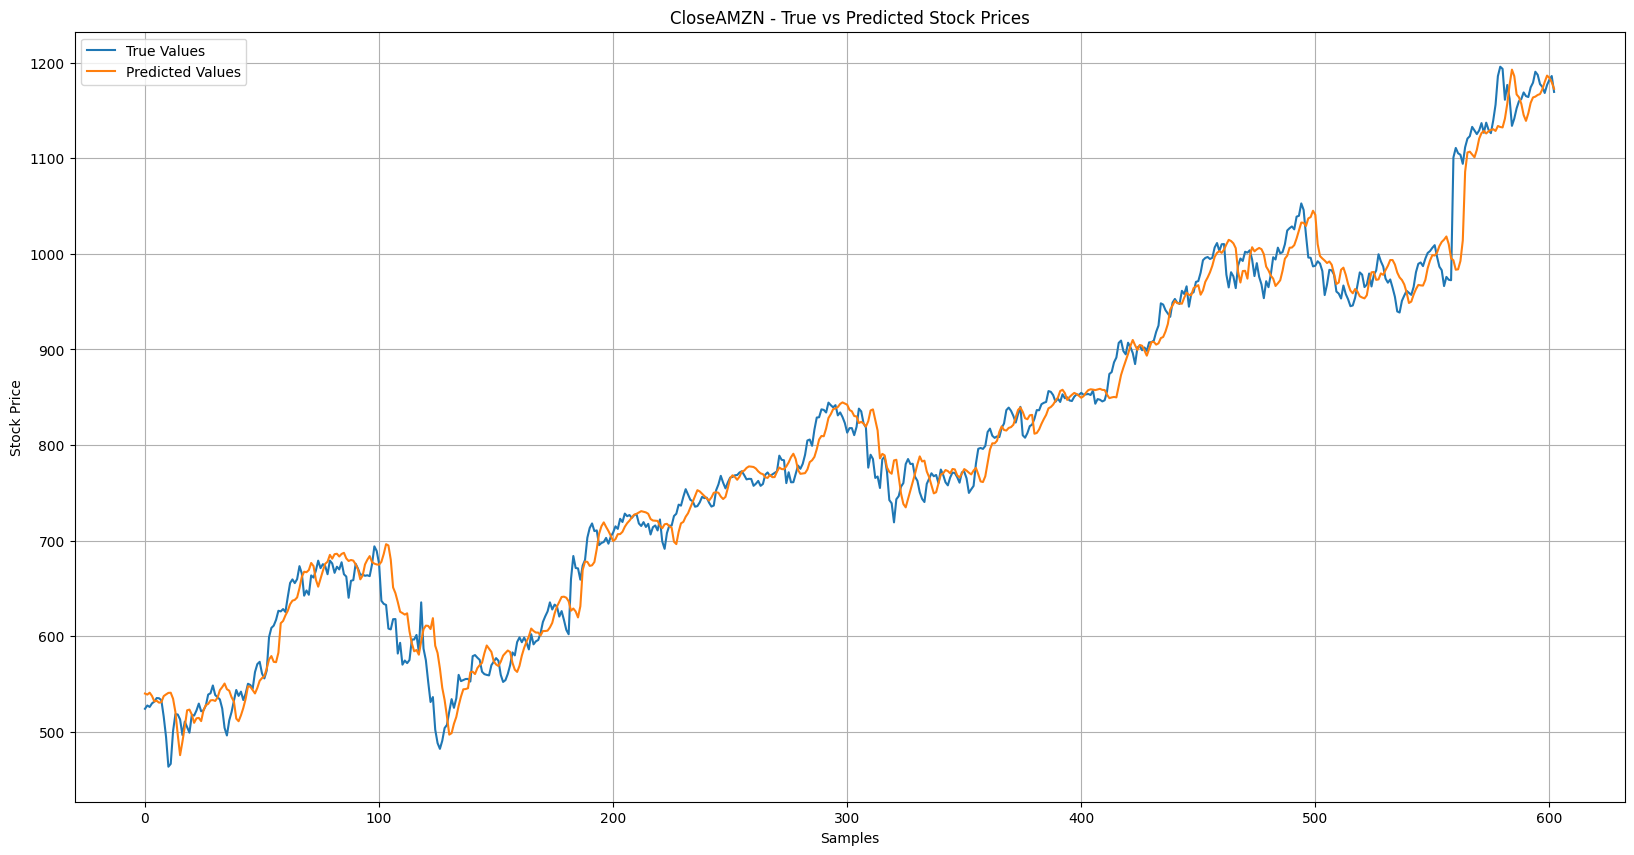

In [22]:
# Predict on the test data and plot
y_pred = final_simple_rnn_model.predict(X_test)

plt.figure(figsize=(20, 10))
plt.plot(y_test, label='True Values')
plt.plot(y_pred, label='Predicted Values')
plt.title('CloseAMZN - True vs Predicted Stock Prices')
plt.xlabel('Samples')
plt.ylabel('Stock Price')
plt.legend()
plt.grid()
plt.show()

It is worth noting that every training session for a neural network is unique. So, the results may vary slightly each time you retrain the model.

In [23]:
# Compute the performance of the model on the testing data set
simple_rnn_mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {simple_rnn_mae}")

Mean Absolute Error (MAE): 18.604795017021015


* On average, the daily closing price of AMZN can be predicted with a Mean Absolute Error (MAE) of 18.60.

### **2.2 Advanced RNN Models** <font color =red> [10 marks] </font>

In this section, we will:
- Create an LSTM or a GRU network
- Tune the network for different hyperparameter values
- View the performance of the optimal model on the test data

#### **2.2.1** <font color =red> [3 marks] </font>
Create a function that builds an advanced RNN model with tunable hyperparameters.

* Using weekly data to train an advanced RNN model with a 8-weeks (2 months) window size.

In [24]:
# Create data instances from the master data frame using decided window size and window stride
window_size = 8
window_stride = 1
train_test_split_ratio = 0.2
X_train, y_train, X_test, y_test = create_data_points(weekly_data, target_names, window_size, window_stride, train_test_split_ratio)

# Check the number of data points generated
print(f'Number of data points generated for training: {len(X_train)}')
print(f'Number of data points generated for testing: {len(X_test)}')

# Check if the datasets are compatible inputs to neural networks
print("TRAINING DATA")
print(f'Shape of input sequences: {X_train.shape}')
print(f'Shape of output sequences: {y_train.shape}')
print("-"*50)
print("TESTING DATA")
print(f'Shape of input sequences: {X_test.shape}')
print(f'Shape of output sequences: {y_test.shape}')

Number of data points generated for training: 494
Number of data points generated for testing: 124
TRAINING DATA
Shape of input sequences: (494, 8, 20)
Shape of output sequences: (494, 1)
--------------------------------------------------
TESTING DATA
Shape of input sequences: (124, 8, 20)
Shape of output sequences: (124, 1)


In [25]:
# Define a function to create a model and specify default values for hyperparameters
def create_advanced_rnn_model(input_shape, activation, loss, optimizer, rnn_units):
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(LSTM(rnn_units, activation=activation))
    model.add(Dense(1))
    model.compile(loss=loss, optimizer=optimizer, metrics=['mean_absolute_error'])
    return model

#### **2.2.2** <font color =red> [4 marks] </font>
Perform hyperparameter tuning to find the optimal network configuration.

In [26]:
# Find an optimal configuration
advanced_rnn_models = []
advanced_rnn_configurations = []

for configuration in configurations_grid:
    print(f"\nTraining with config: {configuration}")
    model = create_advanced_rnn_model(input_shape=(X_train.shape[1], X_train.shape[2]),
                                    activation=configuration['activation'],
                                    loss=configuration['loss'],
                                    optimizer=configuration['optimizer'],
                                    rnn_units=configuration['units'])
    history = model.fit(X_train, y_train, batch_size=32, epochs=20, validation_data=(X_test, y_test), callbacks=[early_stopping])
    advanced_rnn_models.append(model)
    advanced_rnn_configurations.append(configuration)


Training with config: {'activation': 'relu', 'loss': 'mse', 'optimizer': 'adam', 'units': 32}
Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 44413.4727 - mean_absolute_error: 175.3814 - val_loss: 661198.6250 - val_mean_absolute_error: 793.3110
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 42900.4961 - mean_absolute_error: 173.1677 - val_loss: 640667.1875 - val_mean_absolute_error: 781.3030
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 44780.9219 - mean_absolute_error: 178.0631 - val_loss: 405419.6250 - val_mean_absolute_error: 622.1318
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16124.8877 - mean_absolute_error: 100.3563 - val_loss: 25517.2461 - val_mean_absolute_error: 147.4744
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2774.2859 - mean_absolute_error: 39.0158 - val_loss: 97044.8047 - val_mean_absolute_error: 300.8312
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2186.8809 - mean_absolute_error: 36.4796 - val

In [27]:
# Find the best configuration based on evaluation metrics
best_model = None
best_config = None
best_test_loss = float('inf')

for i, model in enumerate(advanced_rnn_models):
    test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
    print(f"Configuration {i + 1}: {advanced_rnn_configurations[i]} - Test Loss: {test_loss}, Test MAE: {test_mae}")
    
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_model = model
        best_config = advanced_rnn_configurations[i]

print(f"\nBest configuration: {best_config} with Test Loss: {best_test_loss}")

Configuration 1: {'activation': 'relu', 'loss': 'mse', 'optimizer': 'adam', 'units': 32} - Test Loss: 25517.24609375, Test MAE: 147.47439575195312
Configuration 2: {'activation': 'relu', 'loss': 'mse', 'optimizer': 'adam', 'units': 64} - Test Loss: 10445.8203125, Test MAE: 84.39698791503906
Configuration 3: {'activation': 'relu', 'loss': 'mse', 'optimizer': 'adam', 'units': 128} - Test Loss: 6787.173828125, Test MAE: 69.00366973876953
Configuration 4: {'activation': 'relu', 'loss': 'mse', 'optimizer': 'rmsprop', 'units': 32} - Test Loss: 6100.89697265625, Test MAE: 63.6843376159668
Configuration 5: {'activation': 'relu', 'loss': 'mse', 'optimizer': 'rmsprop', 'units': 64} - Test Loss: 11882.3095703125, Test MAE: 88.69143676757812
Configuration 6: {'activation': 'relu', 'loss': 'mse', 'optimizer': 'rmsprop', 'units': 128} - Test Loss: 5373.4033203125, Test MAE: 61.16612243652344
Configuration 7: {'activation': 'relu', 'loss': 'mse', 'optimizer': 'sgd', 'units': 32} - Test Loss: nan, Tes

#### **2.2.3** <font color =red> [3 marks] </font>
Run for optimal RNN Model and show final results.

In [37]:
# Create the model with a combination of potentially optimal hyperparameter values and retrain the model
final_advanced_rnn_model = create_advanced_rnn_model(input_shape=(X_train.shape[1], X_train.shape[2]),
                                                activation=best_config['activation'],
                                                loss=best_config['loss'],
                                                optimizer=best_config['optimizer'],
                                                rnn_units=best_config['units'])
                             
history = final_advanced_rnn_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stopping])

final_advanced_rnn_model.summary()

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 174.0981 - mean_absolute_error: 174.0981 - val_loss: 434.4010 - val_mean_absolute_error: 434.4010
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 66.1188 - mean_absolute_error: 66.1188 - val_loss: 88.8149 - val_mean_absolute_error: 88.8149
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 40.2414 - mean_absolute_error: 40.2414 - val_loss: 98.4317 - val_mean_absolute_error: 98.4317
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 35.7392 - mean_absolute_error: 35.7392 - val_loss: 101.6337 - val_mean_absolute_error: 101.6337
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 36.6772 - mean_absolute_error: 36.6772 - val_loss: 67.9445 - val_mean_absolute_error: 67.9445
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 34.2034 - mean_absolute_error: 34.2034 - val_loss: 110.7989 - val_mean_absolute_error: 110.7989
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 32.2732 - mean_absolut

Model: "sequential_77"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_40 (LSTM)                  │ (None, 64)             │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,652 (170.52 KB)

 Trainable params: 21,825 (85.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 21,827 (85.27 KB)

In [38]:
# Compute the performance of the model on the testing data set
y_pred = final_advanced_rnn_model.predict(X_test)

advanced_rnn_mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {advanced_rnn_mae}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Mean Absolute Error (MAE): 67.94452428411668


* On average, the weekly mean closing price of AMZN can be predicted with a Mean Absolute Error (MAE) of 67.94.

Plotting the actual vs predicted values

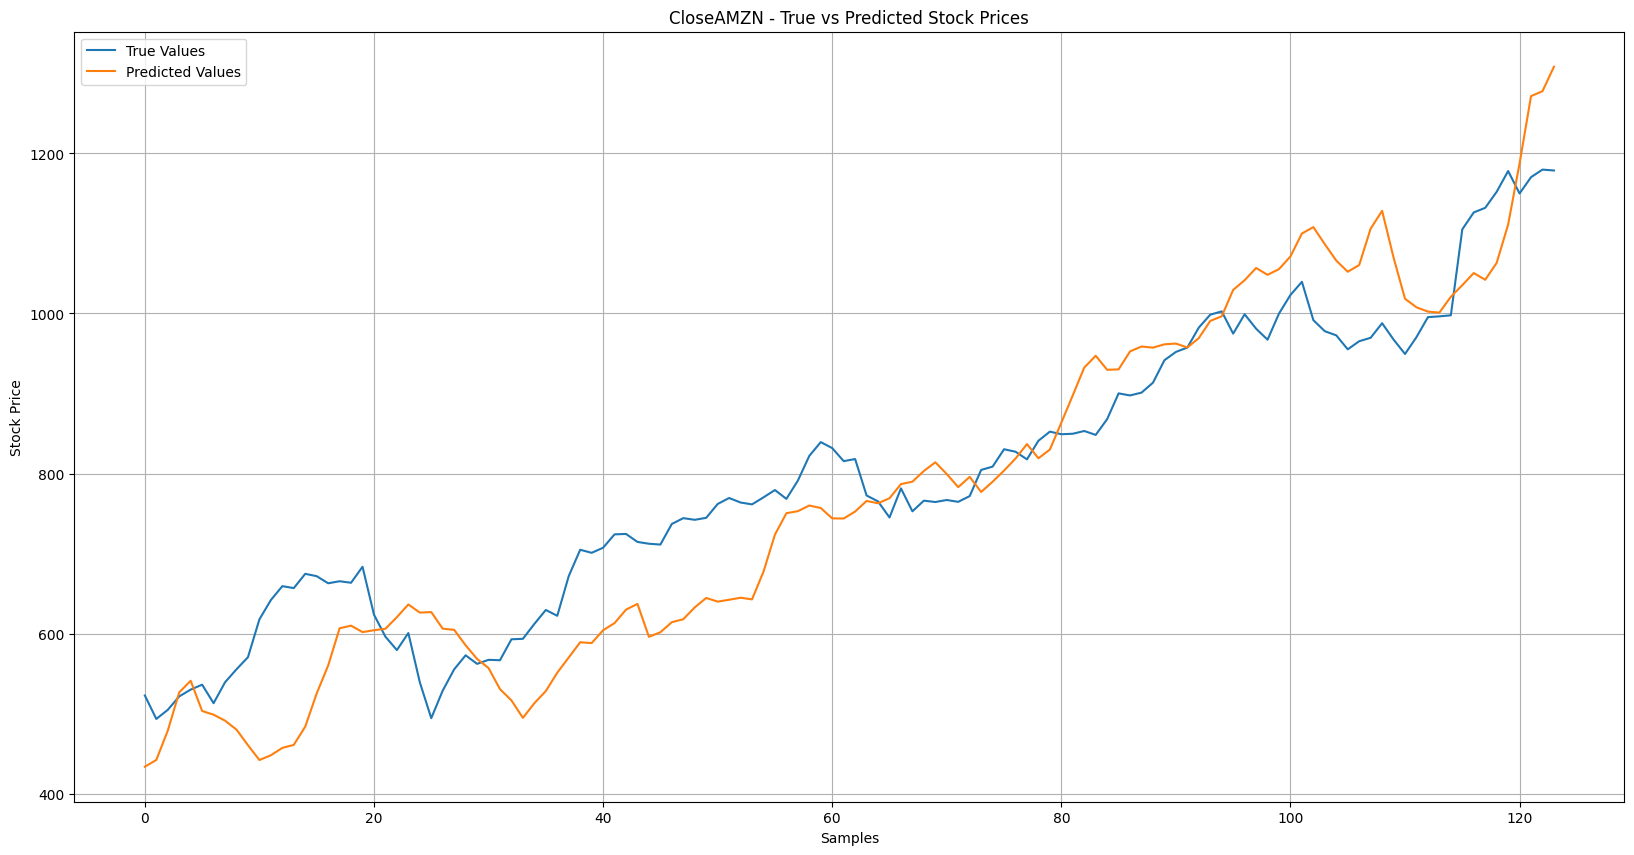

In [39]:
# Predict on the test data
plt.figure(figsize=(20, 10))
plt.plot(y_test, label='True Values')
plt.plot(y_pred, label='Predicted Values')
plt.title('CloseAMZN - True vs Predicted Stock Prices')
plt.xlabel('Samples')
plt.ylabel('Stock Price')
plt.legend()
plt.grid()
plt.show()

## **3 Predicting Multiple Target Variables** <font color =red> [OPTIONAL] </font>

In this section, we will use recurrent neural networks to predict stock prices for more than one company.

### **3.1 Data Preparation**

#### **3.1.1**
Create testing and training instances for multiple target features.

You can take the closing price of all four companies to predict here.

In [40]:
# Create data instances from the master data frame using a window size of 65, a window stride of 5 and a test size of 20%
# Specify the list of stock names whose 'Close' values you wish to predict using the 'target_names' parameter



In [41]:
# Check the number of data points generated



### **3.2 Run RNN Models**

#### **3.2.1**
Perform hyperparameter tuning to find the optimal network configuration for Simple RNN model.

In [42]:
# Find an optimal configuration of simple RNN



In [43]:
# Find the best configuration



In [44]:
# Create an RNN model with a combination of potentially optimal hyperparameter values and retrain the



In [45]:
# Compute the performance of the model on the testing data set



In [46]:
# Plotting the actual vs predicted values for all targets



#### **3.2.2**
Perform hyperparameter tuning to find the optimal network configuration for Advanced RNN model.

In [47]:
# Find an optimal configuration of advanced RNN



In [48]:
# Find the best configuration



In [49]:
# Create a model with a combination of potentially optimal hyperparameter values and retrain the model



In [50]:
# Compute the performance of the model on the testing data set



In [51]:
# Plotting the actual vs predicted values for all targets



## **4 Conclusion** <font color =red> [5 marks] </font>

### **4.1 Conclusion and insights** <font color =red> [5 marks] </font>

#### **4.1.1** <font color =red> [5 marks] </font>
Conclude with the insights drawn and final outcomes and results.

* We analyzed the closing stock prices of AMZN, observing a consistent upward trend since 2006.

* The stock prices of AMZN, GOOGL and IBM were found to be highly correlated, which shows similar market behavior.

* Fluctuations and noise are more in daily and weekly data, and decrease as the time frame increases.

* While yearly data is smoother, for our analysis, we will use daily, weekly and monthly data to balance the resolution and trend visibility.

* For the Simple RNN model, we used daily closing prices of AMZN with a 5-days (1-week) window size.

* For the advanced model, we implemented LSTM, using weekly data with an 8-weeks (2-month) window size.

* A total of 36 different network configurations were initially trained for 20 epochs to determine the optimal setup.

* After identifying the best configuration, the model was retrained for 50 epochs to enhance performance.

* Early stopping was used to prevent overfitting during training.

* Training time was less than 1 minute, due to the relatively small number of data points.

* The Simple RNN model achieved an average Mean Absolute Error (MAE) of 18.60 in predicting daily closing prices, which is impressive given the median AMZN closing price of 205.44 and a maximum closing price of 1195.83.

* The Advanced RNN (LSTM) model achieved an MAE of 67.94 for weekly average predictions, which is reasonable for medium-term forecasting but could be further improved with additional features or data.